In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年04月02日 19时06分25秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
fadata = cfe.data.read_erythroid_lineage(n_obs=500)
fadata

AnnData object with n_obs × n_vars = 500 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

AnnData object with n_obs × n_vars = 500 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'milestone_color', 'milestone'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe', 'milestone_color_dict', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

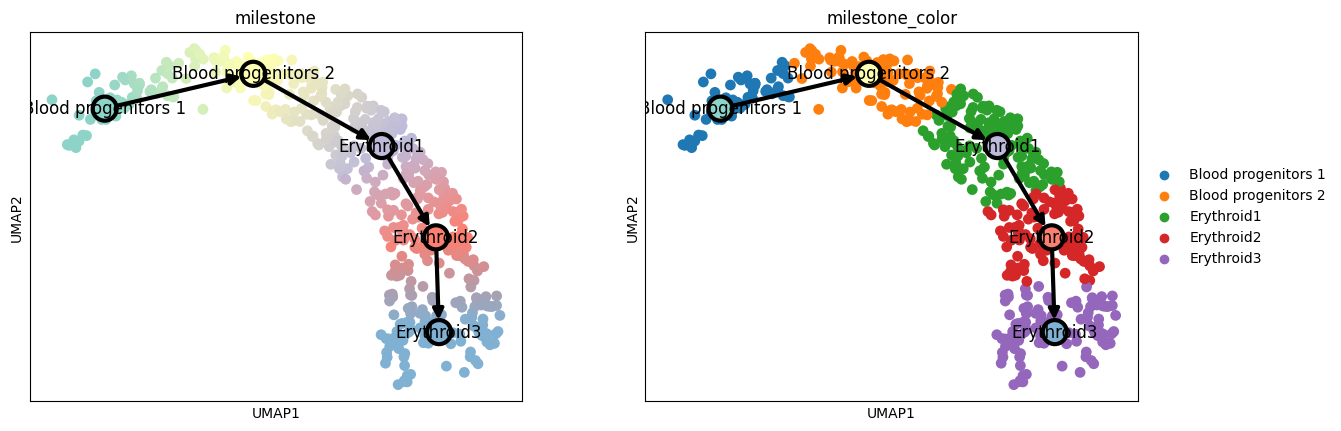

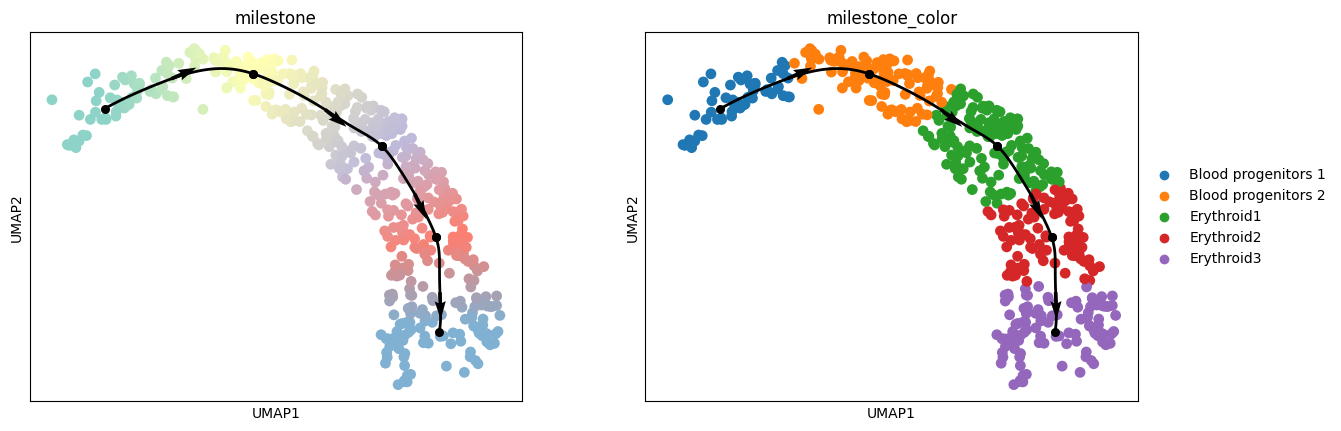

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年04月02日 19时06分31秒] INFO     find wrapper type: directed                                                 


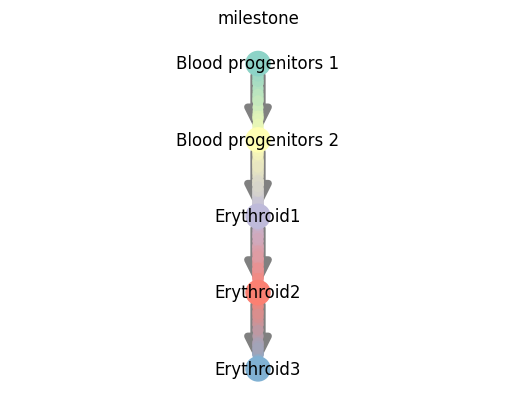

In [4]:
cfe.plot.plot_wrapper(fadata)

[2025年04月02日 19时06分33秒] INFO     Loaded function: <function cf_palantir at 0x76b55b922dd0> from              
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_palantir.py                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76b55af53ca0>                                                                   


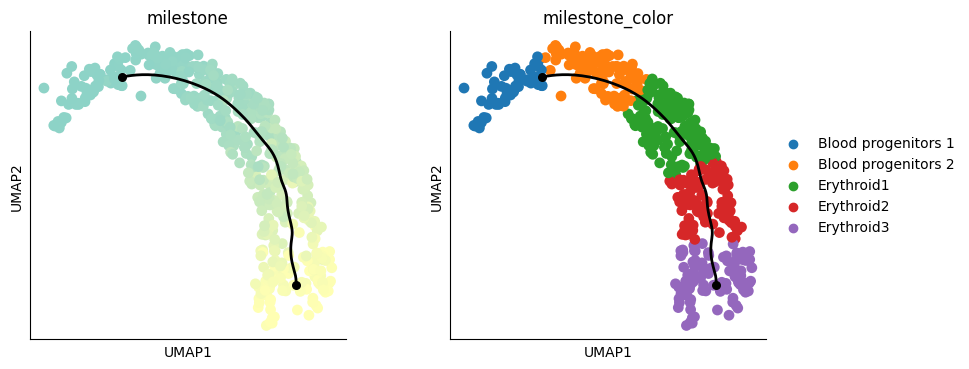

In [5]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["palantir"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)